# **Classification of Pomelo Leaf Diseases Using the VGG16**

This system is designed to detect 4 categories of leaf conditions:
1. **Pomelo_Healthy** (Healthy Leaves)
2. **Pomelo_Cephaleuros_virescens** (Algal Spot Disease)
3. **Pomelo_Leaf_Miner** (Leaf Miner Pest)
4. **Pomelo_Orange_Mold** (Orange Mould Disease)

## Import

In [7]:
import kagglehub
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

## Downloading Datasets from Kaggle

---



In [8]:
path = kagglehub.dataset_download("trung272004/data-leaf-disease-detection-15k")

print("Path to dataset files:", path)

100%|██████████| 142M/142M [00:01<00:00, 149MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/trung272004/data-leaf-disease-detection-15k/versions/1


## **Preprocessing**

In [9]:
dataset_path = "/root/.cache/kagglehub/datasets/trung272004/data-leaf-disease-detection-15k/versions/1"
train_dir = os.path.join(dataset_path, 'train')
val_dir = os.path.join(dataset_path, 'val')

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

### Filtering Pomelo Varieties
Explicitly specify ONLY the "pomelo" folder that we want to retrieve

In [10]:
pomelo_classes = [
    'Pomelo_Cephaleuros_virescens',
    'Pomelo_Healthy',
    'Pomelo_Leaf_Miner',
    'Pomelo_Orange_Mold'
]

#### Pomelo train data

In [11]:
print("Loading Pomelo Specific Training Data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    class_names=pomelo_classes, # Automatic filter
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

Loading Pomelo Specific Training Data...
Found 5000 files belonging to 4 classes.


#### Pomelo val data

In [12]:
print("Loading Pomelo Specific Validation Data...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    class_names=pomelo_classes, # Automatic filter
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

Loading Pomelo Specific Validation Data...
Found 475 files belonging to 4 classes.


Performance Optimization

In [13]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Print the categories that were successfully filtered

In [14]:
print("Disease categories successfully filtered:")
print(pomelo_classes)

Disease categories successfully filtered:
['Pomelo_Cephaleuros_virescens', 'Pomelo_Healthy', 'Pomelo_Leaf_Miner', 'Pomelo_Orange_Mold']


## **Transfer Learning VGG16**
At this stage, we take the base architecture from the VGG16 model and then modify the output layer to specifically classify the 4 categories of Pomelo leaf diseases.

Download the base model

In [15]:
base_model = VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Freeze the base layer so that its knowledge isn't corrupted during training

In [16]:
base_model.trainable = False

Build a new model specifically for Pomelo

In [17]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),          # Meratakan fitur gambar
    layers.Dense(128, activation='relu'),     # Lapisan otak tambahan untuk berpikir
    layers.Dropout(0.2),                      # Mencegah model terlalu 'menghafal' (overfitting)
    layers.Dense(4, activation='softmax')     # OUTPUT: 4 kategori penyakit jeruk bali
])

Compile the model

In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',   # Digunakan karena label data kita berupa angka (0, 1, 2, 3)
    metrics=['accuracy']
)

view the architecture summary that was just created

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 66,180 (258.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

# **Starting model training**

In [20]:
EPOCHS = 10

print("Starting model training...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

Starting model training...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 261ms/step - accuracy: 0.6530 - loss: 0.9520 - val_accuracy: 0.7642 - val_loss: 0.5980
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 168ms/step - accuracy: 0.7982 - loss: 0.5349 - val_accuracy: 0.8147 - val_loss: 0.4730
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 178ms/step - accuracy: 0.8414 - loss: 0.4117 - val_accuracy: 0.8400 - val_loss: 0.4304
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 184ms/step - accuracy: 0.8668 - loss: 0.3479 - val_accuracy: 0.8168 - val_loss: 0.4711
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 177ms/step - accuracy: 0.8842 - loss: 0.3068 - val_accuracy: 0.8505 - val_loss: 0.4120
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 178ms/step - accuracy: 0.8996 - loss: 0.2691 - val_accuracy: 0.8442 - val_loss: 0.3981
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 180ms/step - accuracy: 0.9108 - loss: 0.2398 - val_accuracy: 0.8274 - val_loss: 0.4198
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 179ms/step -

Save the model

In [21]:
model.save('pomelo_disease_model.h5')
print("The AI model has been successfully saved!")

The AI model has been successfully saved!


# **Accuracy Chart**

Retrieve the accuracy data from the 'history' variable resulting from the training

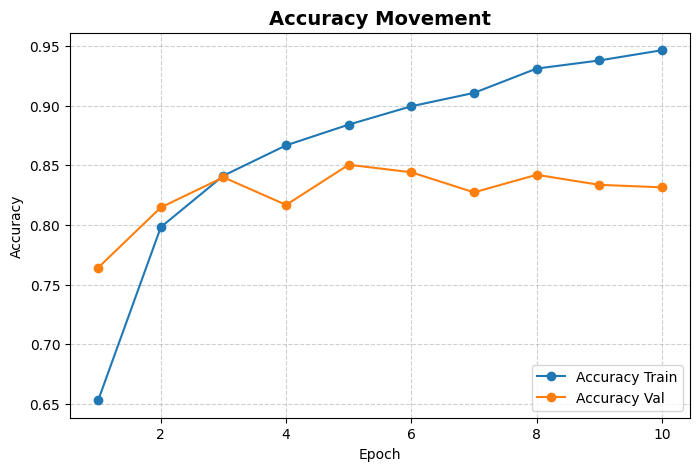

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs_range = range(1, len(acc) + 1)

# Creating an Accuracy Graph Canvas
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label='Accuracy Train', marker='o')
plt.plot(epochs_range, val_acc, label='Accuracy Val', marker='o')

# Graphical settings
plt.legend(loc='lower right')
plt.title('Accuracy Movement', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# **Loss Chart**

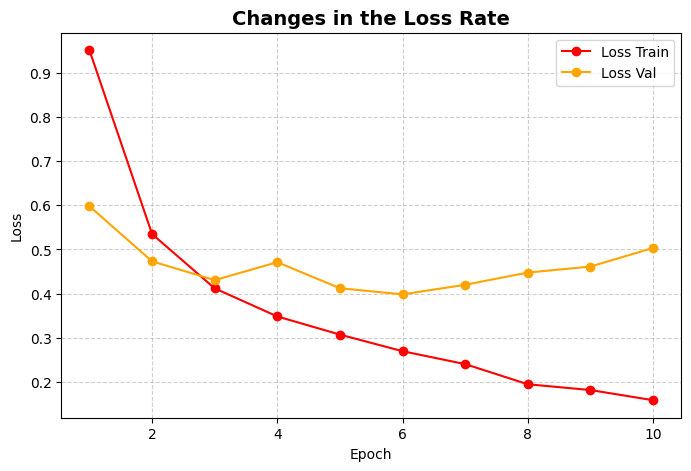

In [23]:
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(loss) + 1)

# Creating an Loss Graph Canvas
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label='Loss Train', marker='o', color='red')
plt.plot(epochs_range, val_loss, label='Loss Val', marker='o', color='orange')

# Graphical settings
plt.legend(loc='upper right')
plt.title('Changes in the Loss Rate', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# **Confusion Matrix**

In [ ]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    class_names=pomelo_classes,
    shuffle=False, # VERY IMPORTANT: Do not shuffle the true labels so that the order remains the same
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

Preparing the data without randomizing it...
Found 475 files belonging to 4 classes.


Extracting the original true labels from the dataset

In [ ]:
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

Extracting the original true labels...


Asking AI to predict the entire image

In [ ]:
y_pred_probs = model.predict(test_dataset)

AI is predicting an image...
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 232ms/step


Convert a decimal number to a guess index (0, 1, 2, or 3)

In [27]:
y_pred = np.argmax(y_pred_probs, axis=1)

Creating a Confusion Matrix

In [28]:
cm = confusion_matrix(y_true, y_pred)

Drawing a Confusion Matrix Visualization

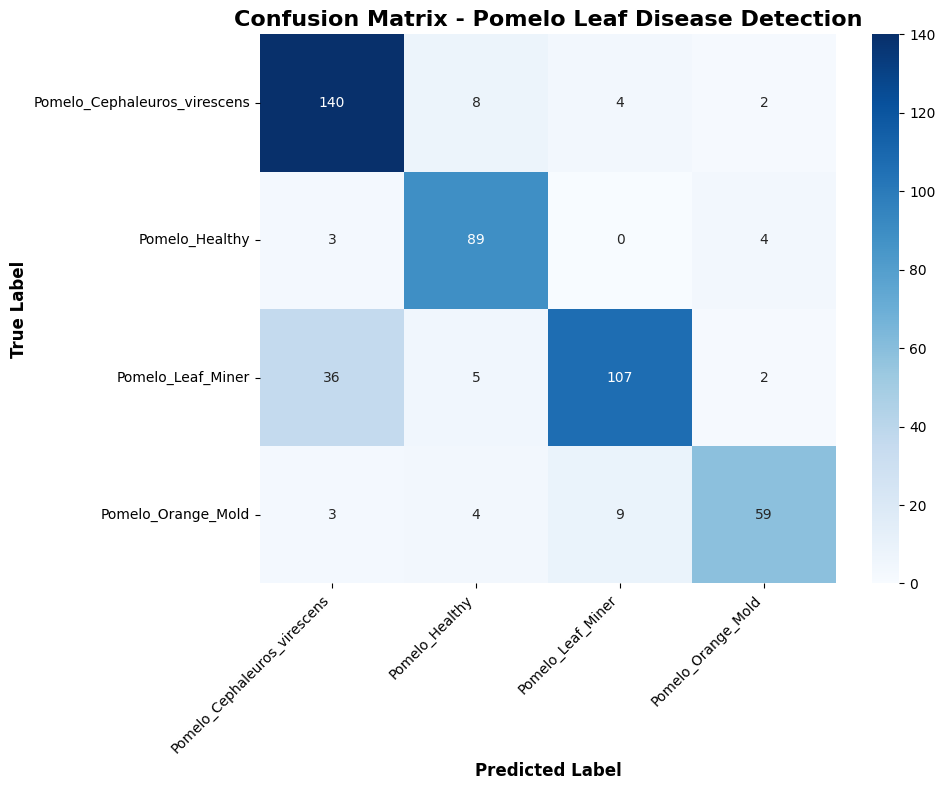

In [29]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=pomelo_classes,
            yticklabels=pomelo_classes)

plt.title('Confusion Matrix - Pomelo Leaf Disease Detection', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Show the Classification Report

In [30]:
print("CLASSIFICATION REPORT")
print(classification_report(y_true, y_pred, target_names=pomelo_classes))

CLASSIFICATION REPORT
                              precision    recall  f1-score   support

Pomelo_Cephaleuros_virescens       0.77      0.91      0.83       154
              Pomelo_Healthy       0.84      0.93      0.88        96
           Pomelo_Leaf_Miner       0.89      0.71      0.79       150
          Pomelo_Orange_Mold       0.88      0.79      0.83        75

                    accuracy                           0.83       475
                   macro avg       0.85      0.83      0.83       475
                weighted avg       0.84      0.83      0.83       475



# **Saving the Class Mapping List to JSON**
List of diseases affecting Pomelo (must be listed in the exact same order as during the training)

In [31]:
pomelo_classes = [
    'Pomelo_Cephaleuros_virescens',
    'Pomelo_Healthy',
    'Pomelo_Leaf_Miner',
    'Pomelo_Orange_Mold'
]

The name of the JSON file to be saved

In [32]:
file_nama = 'pomelo_labels.json'

Saving a list of data to a JSON file

In [33]:
with open(file_nama, 'w') as f:
    json.dump(pomelo_classes, f, indent=4)

print(f"The list of class labels has been successfully saved to the file: {file_nama}")

The list of class labels has been successfully saved to the file: pomelo_labels.json
